In [1]:
import xarray as xr
import numpy as np
import math
import datetime
import yaml
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

In [2]:
ds = xr.open_dataset('gs://leap-persistent/fayamanda/reconstructions/pCO2_LEAP_XGBoost-fco2-residual-reconstructed_198201-202312.zarr', engine='zarr')
resid24_pco2 = ds.fco2_reconstructed.rename({'ylat': 'lat','xlon': 'lon'})

ds = xr.open_dataset('gs://leap-persistent/fayamanda/reconstructions/pCO2_LEAP_XGBoost-fco2-xco2_seas-residual-reconstructed_TBparams_198201-202312.zarr', engine='zarr')
resid24_pco2TB = ds.fco2_reconstructed.rename({'ylat': 'lat','xlon': 'lon'})

ds = xr.open_dataset('gs://leap-persistent/fayamanda/reconstructions/pCO2_LEAP_XGBoost-delta_varyP-residual-reconstructed_TBparams_198201-202312.zarr', engine='zarr')
resid24_deltaVP = ds.delta_reconstructed.rename({'ylat': 'lat','xlon': 'lon'})
resid24_pco2DVP = ds.fco2_reconstructed.rename({'ylat': 'lat','xlon': 'lon'})

In [3]:
#Variables needed for flux calculation
ds = xr.open_dataset('gs://leap-persistent/fayamanda/online_data/variables_needed_for_flux_calc_1959-2023.zarr', engine='zarr')

ice_weighting = 1 - ds.ice.fillna(0)
coef_convert = 87.6/1000

In [4]:
delta_resid24 = resid24_pco2 - ds.atmos_fco2.sel(time=slice(resid24_pco2.time[0],resid24_pco2.time[-1])) 
delta_resid24TB = resid24_pco2TB - ds.atmos_fco2.sel(time=slice(resid24_pco2TB.time[0],resid24_pco2TB.time[-1])) 
delta_resid24DVP = resid24_pco2DVP - ds.atmos_fco2.sel(time=slice(resid24_pco2DVP.time[0],resid24_pco2DVP.time[-1]))

In [5]:
weights = np.cos(np.deg2rad(resid24_pco2.lat))
weights.name = "weights"

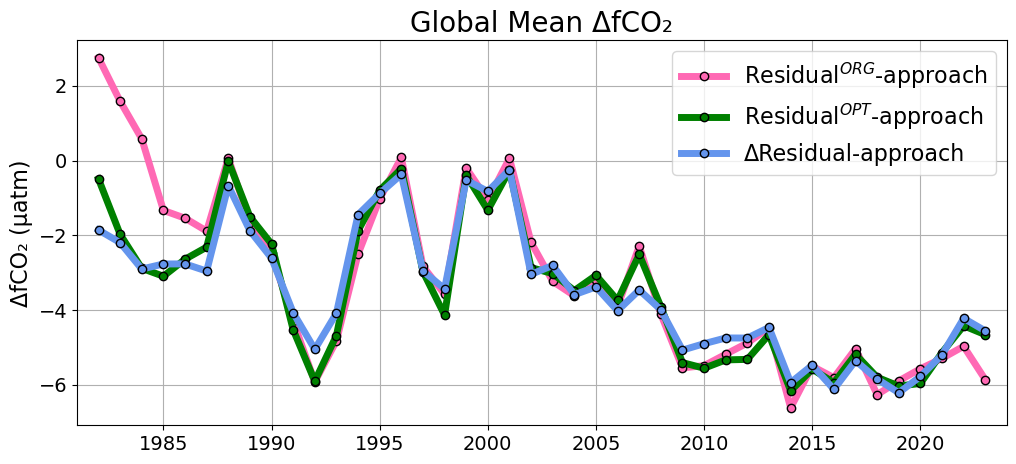

In [6]:
fig = plt.figure(figsize=(12,5))

plt.plot(range(1982,2024),(delta_resid24.weighted(weights).mean(['lon','lat']).groupby("time.year").mean("time")),'-',
         marker='o',markersize=6, markeredgecolor='black', markeredgewidth=1, color='hotpink',linewidth=5,label=r'Residual$^{ORG}$-approach')
plt.plot(range(1982,2024),(delta_resid24TB.weighted(weights).mean(['lon','lat']).groupby("time.year").mean("time")),'-',
         marker='o',markersize=6, markeredgecolor='black', markeredgewidth=1, color='green',linewidth=5,label=r'Residual$^{OPT}$-approach')
plt.plot(range(1982,2024),(delta_resid24DVP.weighted(weights).mean(['lon','lat']).groupby("time.year").mean("time")),'-',
         marker='o',markersize=6, markeredgecolor='black', markeredgewidth=1, color='cornflowerblue',linewidth=5,label='ΔResidual-approach') #not
plt.title('Global Mean ΔfCO₂',fontsize=20)
plt.legend(fontsize=16)
plt.ylabel('ΔfCO₂ (µatm)', fontsize=16)
plt.xlim([1981, 2024])
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True)

# plt.savefig("/home/jovyan/obs_dfco2.pdf", transparent=True, bbox_inches='tight')

In [7]:
org_opt = (delta_resid24.weighted(weights).mean(['lon','lat']).groupby("time.year").mean("time") - delta_resid24TB.weighted(weights).mean(['lon','lat']).groupby("time.year").mean("time"))#.sel(year=slice(1990,2020))
org_del = (delta_resid24.weighted(weights).mean(['lon','lat']).groupby("time.year").mean("time") - delta_resid24DVP.weighted(weights).mean(['lon','lat']).groupby("time.year").mean("time"))#.sel(year=slice(1990,2020))

In [8]:
resid24_flux_calc = ds.K0.sel(time=slice(resid24_pco2.time[0],resid24_pco2.time[-1])) \
    * ds.kw.sel(time=slice(resid24_pco2.time[0],resid24_pco2.time[-1])) \
    * delta_resid24 \
    * ice_weighting.sel(time=slice(resid24_pco2.time[0],resid24_pco2.time[-1]))  * coef_convert # mol/m2/yr

resid24TB_flux_calc = ds.K0.sel(time=slice(resid24_pco2.time[0],resid24_pco2.time[-1])) \
    * ds.kw.sel(time=slice(resid24_pco2.time[0],resid24_pco2.time[-1])) \
    * delta_resid24TB \
    * ice_weighting.sel(time=slice(resid24_pco2.time[0],resid24_pco2.time[-1]))  * coef_convert # mol/m2/yr

resid24DVP_flux_calc = ds.K0.sel(time=slice(resid24_pco2DVP.time[0],resid24_pco2DVP.time[-1])) \
    * ds.kw.sel(time=slice(resid24_pco2DVP.time[0],resid24_pco2DVP.time[-1])) \
    * delta_resid24DVP \
    * ice_weighting.sel(time=slice(resid24_pco2DVP.time[0],resid24_pco2DVP.time[-1]))  * coef_convert # mol/m2/yr

In [9]:
sf = xr.open_dataset('gs://leap-persistent/fayamanda/online_data/SeaFlux/processed/Seaflux_2024_beta.zarr', engine='zarr')
seaflux_area = sf.area
area = seaflux_area

import requests

url = 'https://github.com/RECCAP2-ocean/R2-shared-resources/raw/master/data/regions/RECCAP2_region_masks_all_v20221025.nc'
r = requests.get(url, allow_redirects=True)

open('mask.nc', 'wb').write(r.content)
reccap_mask = xr.open_dataset('mask.nc')
reccap_mask['lon'] = list(map(lambda x: x-360 if x>180 else x, reccap_mask['lon'].values))
reccap_mask = reccap_mask.sortby('lon')

In [10]:
flux_tmp = resid24_flux_calc * area *12 
resid24_flux_calc_global = flux_tmp.where(reccap_mask['seamask']>=1).sum(['lat','lon'])/(10**15)
resid24_flux_calc_global_annual = resid24_flux_calc_global.groupby("time.year").mean("time")

flux_tmp = resid24TB_flux_calc * area *12 
resid24TB_flux_calc_global = flux_tmp.where(reccap_mask['seamask']>=1).sum(['lat','lon'])/(10**15)
resid24TB_flux_calc_global_annual = resid24TB_flux_calc_global.groupby("time.year").mean("time")

flux_tmp = resid24DVP_flux_calc * area *12 
resid24DVP_flux_calc_global = flux_tmp.where(reccap_mask['seamask']>=1).sum(['lat','lon'])/(10**15)
resid24DVP_flux_calc_global_annual = resid24DVP_flux_calc_global.groupby("time.year").mean("time")

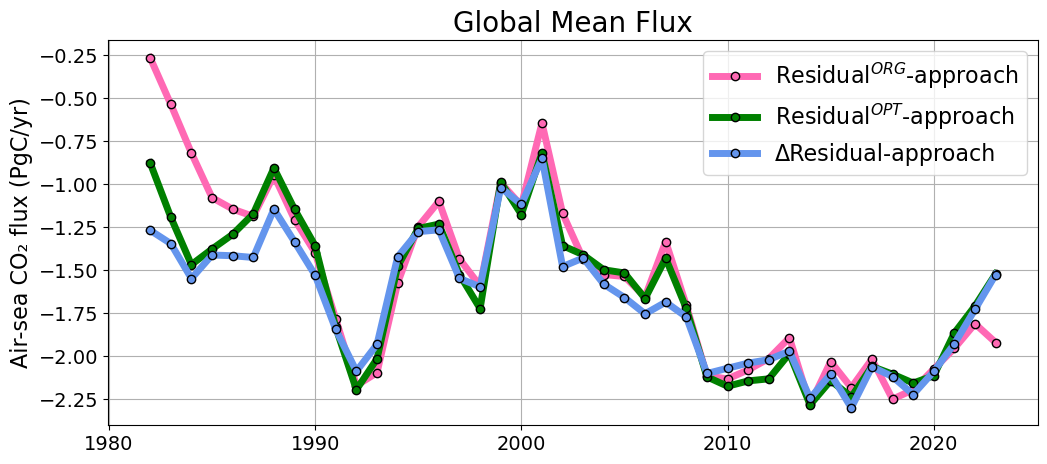

In [11]:
fig = plt.figure(figsize=(12,5))

plt.plot(range(1982,2024),(resid24_flux_calc_global_annual),'-',
         marker='o',markersize=6, markeredgecolor='black', markeredgewidth=1, color='hotpink',linewidth=5,label = r'Residual$^{ORG}$-approach')
plt.plot(range(1982,2024),(resid24TB_flux_calc_global_annual),'-',
         marker='o',markersize=6, markeredgecolor='black', markeredgewidth=1, color='green',linewidth=5,label = r'Residual$^{OPT}$-approach' )
plt.plot(range(1982,2024),(resid24DVP_flux_calc_global_annual),'-',
         marker='o',markersize=6, markeredgecolor='black', markeredgewidth=1, color='cornflowerblue',linewidth=5,label='ΔResidual-approach')
plt.title('Global Mean Flux',fontsize=20)
plt.legend(fontsize=16)
plt.grid(True)

plt.ylabel('Air-sea CO\u2082 flux (PgC/yr)',fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)

# plt.savefig("/home/jovyan/obs_fluxes.pdf", transparent=True, bbox_inches='tight')

# GCB 2024 values

In [12]:
df = pd.read_csv('gs://leap-persistent/abbysh/2024_data_products/Global_Carbon_Budget_2024_OceanSink.csv',na_values=['NaN', 'NA', 'NULL', 'nan',''])

In [13]:
gcb_models = df.iloc[30:96, 4:14]
gcb_models['year'] = df.iloc[30:96, 0]
gcb_models.columns = gcb_models.iloc[0] 
gcb_models = gcb_models[1:] 
gcb_models2 = gcb_models.set_index('year')
gcb_models2.index.name = 'Year'
gcb_models2 = gcb_models2.astype(float)

gcb_products = df.iloc[30:96, 18:27]
gcb_products['year'] = df.iloc[30:96, 0]
gcb_products.columns = gcb_products.iloc[0] 
gcb_products = gcb_products[1:] 
gcb_products2 = gcb_products.set_index('year')
gcb_products2.index.name = 'Year'
gcb_products2 = gcb_products2.astype(float)

gcb_mean = df.iloc[30:96, 1:2]
gcb_mean['year'] = df.iloc[30:96, 0]
gcb_mean.columns = gcb_mean.iloc[0] 
gcb_mean = gcb_mean[1:] 
gcb_mean2 = gcb_mean.set_index('year')
gcb_mean2.index.name = 'Year'
gcb_mean2 = gcb_mean2.astype(float)

gcb_products_xr = gcb_products2.to_xarray()
gcb_models_xr = gcb_models2.to_xarray()
gcb_mean_xr = gcb_mean2.to_xarray()

gcb_products_xr['Year'] = gcb_products_xr['Year'].astype('int64')
gcb_models_xr['Year'] = gcb_models_xr['Year'].astype('int64')
gcb_mean_xr['Year'] = gcb_mean_xr['Year'].astype('int64')

gcb_products_xr = gcb_products_xr*-1
gcb_models_xr = gcb_models_xr*-1
gcb_mean_xr = gcb_mean_xr*-1

In [19]:
Products = ['CMEMS-LSCE-FFNN','Jena-MLS','CSIR-ML6','JMA-MLR','NIES-ML3','OceanSODA-ETHZv2','VLIZ-SOMFFN','LDEO-HPD']
Models = ['ACCESS (CSIRO)','CESM-ETHZ','NEMO3.6-PISCESv2-gas (CNRM)','FESOM-2.1-REcoM3','NEMO-PISCES (IPSL)','MPIOM-HAMOCC6','MRI-ESM2-21','MICOM-HAMOCC (NorESM1-OCv1.2)','NEMO-PlankTOM12','MOM6-COBALT (Princeton)']

yearly_list = [
    gcb_products_xr[pod].sel(Year=slice(1982,2023))
    for pod in Products
]

yearlyP = xr.concat(yearly_list, dim="product")
yearlyP = yearlyP.assign_coords(product=Products)
years = yearlyP['Year'].values
yminP = yearlyP.min(dim='product').values
ymaxP = yearlyP.max(dim='product').values
mean_seriesP = yearlyP.mean(dim='product').values
std_seriesP = yearlyP.std(dim='product').values


yearly_list = [
    gcb_models_xr[mod].sel(Year=slice(1982,2023))
    for mod in Models
]

yearlyM = xr.concat(yearly_list, dim="model")
yearlyM = yearlyM.assign_coords(model=Models)
yminM = yearlyM.min(dim='model').values
ymaxM = yearlyM.max(dim='model').values
mean_seriesM = yearlyM.mean(dim='model').values
std_seriesM = yearlyM.std(dim='model').values

GCB_mean = gcb_mean_xr.GCB.sel(Year=slice(1982,2023))

/tmp/ipykernel_6513/46453623.py:17: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(years, GCB_mean, '-', color='k', linewidth=5, label='GCB Merged mean',linestyle='dashed')


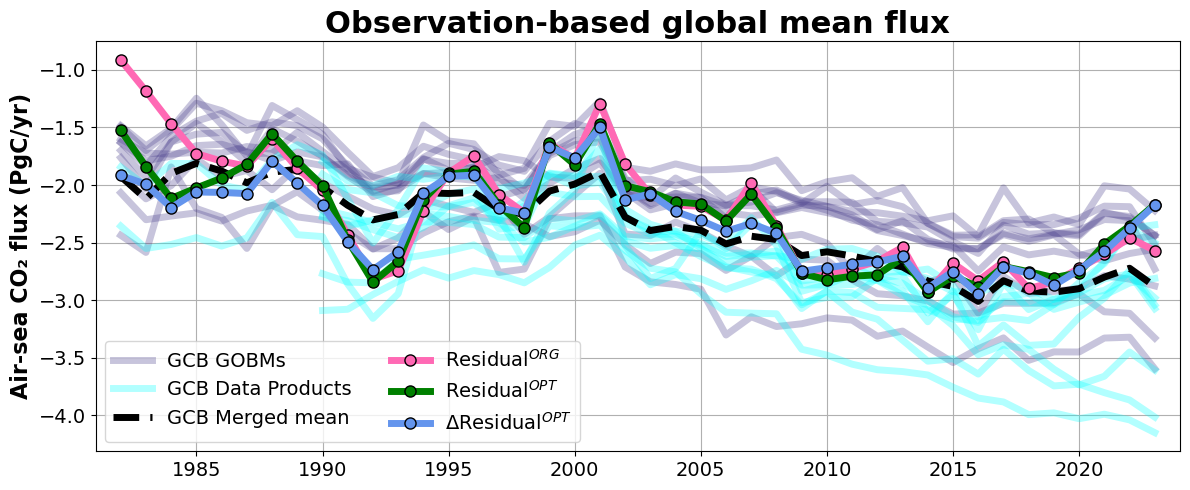

In [23]:
fig = plt.figure(figsize=(12,5))

for m in range(0,9):
    plt.plot(yearlyM.Year,yearlyM.isel(model=m),'darkslateblue',linewidth=5,alpha=.3)
plt.plot(yearlyM.Year,yearlyM.isel(model=9),'darkslateblue',linewidth=5,alpha=.3,label = 'GCB GOBMs') 

plt.plot(range(1982,2024),(gcb_products_xr['JMA-MLR'].sel(Year=slice(1982,2023))),'-',color='cyan',alpha=0.3,linewidth=5, label='GCB Data Products')#, marker='o',markersize=8, markeredgecolor='black', markeredgewidth=1)
plt.plot(range(1982,2024),(gcb_products_xr['LDEO-HPD'].sel(Year=slice(1982,2023))),'-',color='cyan',alpha=0.3,linewidth=5, label='')#, marker='o',markersize=8, markeredgecolor='black', markeredgewidth=1)
plt.plot(range(1982,2024),(gcb_products_xr['NIES-ML3'].sel(Year=slice(1982,2023))),'-',color='cyan',alpha=0.3,linewidth=5, label='')#, marker='o',markersize=8, markeredgecolor='black', markeredgewidth=1)
plt.plot(range(1982,2024),(gcb_products_xr['OceanSODA-ETHZv2'].sel(Year=slice(1982,2023))),'-',color='cyan',alpha=0.3,linewidth=5, label='')#, marker='o',markersize=8, markeredgecolor='black', markeredgewidth=1)
plt.plot(range(1982,2024),(gcb_products_xr['Jena-MLS'].sel(Year=slice(1982,2023))),'-',color='cyan',alpha=0.3,linewidth=5, label='')#, marker='o'#,markersize=8, markeredgecolor='black', markeredgewidth=1)
plt.plot(range(1982,2024),(gcb_products_xr['CSIR-ML6'].sel(Year=slice(1982,2023))),'-',color='cyan',alpha=0.3,linewidth=5, label='')#, marker='o',markersize=8, markeredgecolor='black', markeredgewidth=1)
plt.plot(range(1982,2024),(gcb_products_xr['VLIZ-SOMFFN'].sel(Year=slice(1982,2023))),'-',color='cyan',alpha=0.3,linewidth=5,label='')
plt.plot(range(1982,2024),(gcb_products_xr['CMEMS-LSCE-FFNN'].sel(Year=slice(1982,2023))),'-',color='cyan',alpha=0.3,linewidth=5, label='')#, marker='o',markersize=8, markeredgecolor='black', markeredgewidth=1)
plt.plot(range(1982,2024),(gcb_products_xr['UoEX-UEPFFNU (former called Watson)'].sel(Year=slice(1982,2023))),'-',color='cyan',alpha=0.3,linewidth=5, label='')#, marker='o',markersize=8, markeredgecolor='black', markeredgewidth=1)

plt.plot(years, GCB_mean, '-', color='k', linewidth=5, label='GCB Merged mean',linestyle='dashed')

plt.plot(range(1982,2024),(resid24_flux_calc_global_annual-0.65),'-',color='hotpink',linewidth=5, label=r'Residual$^{ORG}$', marker='o',markersize=8, markeredgecolor='black', markeredgewidth=1)
plt.plot(range(1982,2024),(resid24TB_flux_calc_global_annual-0.65),'-',color='green',linewidth=5, label=r'Residual$^{OPT}$', marker='o',markersize=8, markeredgecolor='black', markeredgewidth=1)
plt.plot(range(1982,2024),(resid24DVP_flux_calc_global_annual-0.65),'-',color='cornflowerblue',linewidth=5, label='ΔResidual$^{OPT}$', marker='o',markersize=8, markeredgecolor='black', markeredgewidth=1)


plt.title('Observation-based global mean flux',fontsize=22, fontweight='bold')
plt.legend(fontsize=14,loc='lower left', ncol=2)
plt.grid(True)
plt.ylabel('Air-sea CO\u2082 flux (PgC/yr)',fontsize=16, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlim([1981, 2024])

plt.tight_layout()
#fig.savefig("/home/jovyan/timeseries_flux.jpg",dpi=300, bbox_inches="tight", transparent=True)